# **Seleccion de variables, EDA y PCA**

### Importar librerias y cargar datos


In [121]:
import pandas as pd
import unicodedata
import re
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import jarque_bera
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [37]:
# 1. Cargar los datos
BASE_DIR = "."

ruta = os.path.join(BASE_DIR, "base_final_narino_cundinamarca.csv")
df_final = pd.read_csv(ruta)


#### Verificacion de dataset

In [38]:
df_final.head()

,Departamento,Municipio,Año,Área Cosechada,Área Sembrada,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),...,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,Rendimiento_lag1,Rendimiento_lag2,Rendimiento_lag3,Rendimiento_rolling3,Rendimiento_vs_media_mun
0,CUNDINAMARCA,ANAPOIMA,2008,234.66,244.87,104.030,0.443322,9397.211458,21.052603,21.534576,...,0.034885,0.288161,-0.041813,0.090587,753.137185,0.410887,NaN,NaN,0.410887,0.000000
1,CUNDINAMARCA,ANAPOIMA,2009,238.67,244.42,109.322,0.458047,7596.002594,21.659576,22.564850,...,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,0.443322,0.410887,NaN,0.427104,0.016218
2,CUNDINAMARCA,ANAPOIMA,2010,244.25,251.16,114.100,0.467144,10091.935886,21.505259,23.381012,...,0.060390,0.094568,0.601869,0.299247,753.137185,0.458047,0.443322,0.410887,0.437418,0.020628
3,CUNDINAMARCA,ANAPOIMA,2011,245.00,247.00,116.000,0.473469,8696.465524,21.023651,21.647125,...,0.015540,0.021867,0.398428,0.166396,753.137185,0.467144,0.458047,0.443322,0.456171,0.022294
4,CUNDINAMARCA,ANAPOIMA,2012,107.00,107.00,53.500,0.500000,7848.365871,21.446869,21.943756,...,-0.069946,-0.136889,-0.022393,0.012682,753.137185,0.473469,0.467144,0.458047,0.466220,0.022896


In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 38 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Departamento                                              1481 non-null   object 
 1   Municipio                                                 1481 non-null   object 
 2   Año                                                       1481 non-null   int64  
 3   Área Cosechada                                            1481 non-null   float64
 4   Área Sembrada                                             1481 non-null   float64
 5   Producción                                                1481 non-null   float64
 6   Rendimiento                                               1481 non-null   float64
 7   Precipitación acumulada anual (mm/año)                    1481 non-null   float64
 8   Temperatura media 

In [40]:

#Crear columnas con log columnas no útiles o redundantes

df_final["log1p_área sembrada"] = np.log1p(df_final["Área Cosechada"])
df_final["log1p_radiación solar acumulada anual (mj/m²/año)"] = np.log1p(
    df_final["Radiación solar acumulada anual (MJ/m²/año)"])


#Eliminar columnas no útiles o redundantes


cols_drop = ["Rendimiento_lag1",
        "Rendimiento_lag2",
        "Rendimiento_lag3",
        "Rendimiento_rolling3",
        "municipio",
        "Rendimiento_vs_media_mun",
        "Área Sembrada",
"Radiación solar acumulada anual (MJ/m²/año)",
"Área Cosechada"]
cols_drop = [c for c in cols_drop if c in df_final.columns]

df_final = df_final.drop(columns=cols_drop)

In [42]:
df_final.head()

,Departamento,Municipio,Año,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad relativa media anual (%),...,SPI3_dic,SPI6_dic,SPI12_dic,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,log1p_área sembrada,log1p_radiación solar acumulada anual (mj/m²/año)
0,CUNDINAMARCA,ANAPOIMA,2008,104.030,0.443322,9397.211458,21.052603,21.534576,20.717682,83.73498,...,-0.660129,0.442474,0.990945,0.034885,0.288161,-0.041813,0.090587,753.137185,5.462390,8.600787
1,CUNDINAMARCA,ANAPOIMA,2009,109.322,0.458047,7596.002594,21.659576,22.564850,21.122711,82.47872,...,-1.038473,-0.650928,-0.561965,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,5.479263,8.646946
2,CUNDINAMARCA,ANAPOIMA,2010,114.100,0.467144,10091.935886,21.505259,23.381012,19.950592,84.22712,...,-0.475811,0.739385,1.536935,0.060390,0.094568,0.601869,0.299247,753.137185,5.502278,8.573215
3,CUNDINAMARCA,ANAPOIMA,2011,116.000,0.473469,8696.465524,21.023651,21.647125,20.361969,85.47486,...,-0.484511,-0.099035,0.412532,0.015540,0.021867,0.398428,0.166396,753.137185,5.505332,8.580160
4,CUNDINAMARCA,ANAPOIMA,2012,53.500,0.500000,7848.365871,21.446869,21.943756,20.838287,81.22755,...,-0.608266,-0.362650,-0.330545,-0.069946,-0.136889,-0.022393,0.012682,753.137185,4.682131,8.629495


In [43]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 32 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Departamento                                              1481 non-null   object 
 1   Municipio                                                 1481 non-null   object 
 2   Año                                                       1481 non-null   int64  
 3   Producción                                                1481 non-null   float64
 4   Rendimiento                                               1481 non-null   float64
 5   Precipitación acumulada anual (mm/año)                    1481 non-null   float64
 6   Temperatura media anual (°C)                              1481 non-null   float64
 7   Máximo de la temperatura media mensual (°C)               1481 non-null   float64
 8   Mínimo de la tempe

In [46]:
#Validar nulos y vacíos

resumen_calidad = pd.DataFrame({
    "columna": df_final.columns,
    "tipo_dato": df_final.dtypes.astype(str).values,
    "nulos": df_final.isna().sum().values,
    "porcentaje_nulos": (df_final.isna().mean() * 100).round(2).values
})

# Contar vacíos solo en columnas tipo texto
vacios = []

for col in df_final.columns:
    if df_final[col].dtype == "object" or pd.api.types.is_string_dtype(df_final[col]):
        vacios_col = df_final[col].astype(str).str.strip().eq("").sum()
    else:
        vacios_col = 0
    
    vacios.append(vacios_col)

resumen_calidad["vacios_texto"] = vacios
resumen_calidad["total_nulos_y_vacios"] = (
    resumen_calidad["nulos"] + resumen_calidad["vacios_texto"]
)

resumen_calidad["porcentaje_total_afectado"] = (
    resumen_calidad["total_nulos_y_vacios"] / len(df_final) * 100
).round(2)

resumen_calidad = resumen_calidad.sort_values(
    "total_nulos_y_vacios",
    ascending=False
)

display(resumen_calidad)

,columna,tipo_dato,nulos,porcentaje_nulos,vacios_texto,total_nulos_y_vacios,porcentaje_total_afectado
0,Departamento,object,0,0.0,0,0,0.0
1,Municipio,object,0,0.0,0,0,0.0
2,Año,int64,0,0.0,0,0,0.0
3,Producción,float64,0,0.0,0,0,0.0
4,Rendimiento,float64,0,0.0,0,0,0.0
5,Precipitación acumulada anual (mm/año),float64,0,0.0,0,0,0.0
6,Temperatura media anual (°C),float64,0,0.0,0,0,0.0
7,Máximo de la temperatura media mensual (°C),float64,0,0.0,0,0,0.0
8,Mínimo de la temperatura media mensual (°C),float64,0,0.0,0,0,0.0
9,Humedad relativa media anual (%),float64,0,0.0,0,0,0.0


## EDA

In [47]:
# Copia de Base para EDA
df_eda = df_final.copy()

# Configuración de columnas


id_cols = ["Departamento", "Municipio"]
time_col = "Año"
target_col = "Rendimiento"


# Ordenar panel
df_eda = df_eda.sort_values(id_cols + [time_col]).reset_index(drop=True)

print("Dimensión del dataset:", df_eda.shape)
print("Años disponibles:", df_eda[time_col].min(), "-", df_eda[time_col].max())
print("Número de municipios:", df_eda[id_cols].drop_duplicates().shape[0])

Dimensión del dataset: (1481, 32)
Años disponibles: 2008 - 2024
Número de municipios: 92


,Departamento,Municipio,anio_min,anio_max,n_anios,n_obs
71,NARINO,IPIALES,2011,2012,2,2
62,NARINO,CUMBAL,2010,2024,9,9
69,NARINO,ILES,2014,2024,11,11
74,NARINO,LA LLANADA,2008,2024,11,11
91,NARINO,TUQUERRES,2013,2024,12,12
...,...,...,...,...,...,...
82,NARINO,PROVIDENCIA,2008,2024,17,17
87,NARINO,SANDONA,2008,2024,17,17
88,NARINO,SANTACRUZ,2008,2024,17,17
89,NARINO,TAMINANGO,2008,2024,17,17


count    92.000000
mean     16.097826
std       2.096883
min       2.000000
25%      16.000000
50%      17.000000
75%      17.000000
max      17.000000
Name: n_anios, dtype: float64


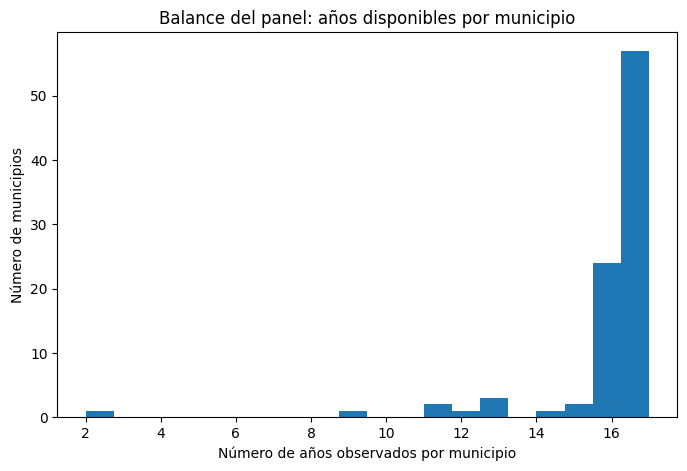

In [52]:
# Número de años por municipio

panel_balance = (
    df_eda
    .groupby(id_cols)
    .agg(
        anio_min=(time_col, "min"),
        anio_max=(time_col, "max"),
        n_anios=(time_col, "nunique"),
        n_obs=(target_col, "size")
    )
    .reset_index()
)

display(panel_balance.sort_values("n_anios"))

print(panel_balance["n_anios"].describe())
plt.figure(figsize=(8, 5))
plt.hist(panel_balance["n_anios"], bins=20)
plt.xlabel("Número de años observados por municipio")
plt.ylabel("Número de municipios")
plt.title("Balance del panel: años disponibles por municipio")
plt.show()

In [44]:
df_final.describe()

,Año,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad relativa media anual (%),Humedad volumétrica media anual del suelo capa 1 (m³/m³),Humedad volumétrica media anual del suelo capa 2 (m³/m³),...,SPI3_dic,SPI6_dic,SPI12_dic,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,log1p_área sembrada,log1p_radiación solar acumulada anual (mj/m²/año)
count,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,...,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000
mean,2016.188386,556.154088,0.929723,4034.531082,17.458259,18.508210,16.492217,85.597330,0.419388,0.419908,...,0.131394,-0.356595,-0.032090,-0.189796,-0.636312,0.161448,0.419971,1773.513156,5.484764,8.723266
std,4.829557,781.607601,0.290802,2558.969615,3.935234,4.246598,3.801230,6.411560,0.034014,0.035677,...,0.751977,0.831653,0.950513,0.504378,0.665562,0.667870,0.561150,720.967997,1.513146,0.077040
min,2008.000000,0.009287,0.064259,857.110217,10.318878,10.685455,9.706207,59.443554,0.284325,0.270451,...,-2.235425,-3.237852,-2.773096,-1.757267,-2.652319,-2.112699,-2.235425,360.017346,0.095310,8.421848
25%,2012.000000,68.320000,0.736490,2426.875808,13.972667,14.680409,13.163727,82.615800,0.400865,0.400962,...,-0.448815,-0.905890,-0.628188,-0.523571,-1.074246,-0.267255,0.090765,1125.498374,4.409217,8.676212
50%,2016.000000,248.310000,0.962962,3223.917512,17.371992,18.348053,16.381695,86.834170,0.417324,0.417480,...,0.092949,-0.339328,-0.104457,-0.189893,-0.580264,0.091284,0.365558,1785.178508,5.676754,8.724785
75%,2020.000000,758.900000,1.119972,4817.122044,20.784536,22.008210,19.803620,89.943350,0.443380,0.445460,...,0.688621,0.189034,0.641705,0.112974,-0.185055,0.579423,0.752954,2395.359310,6.692856,8.774983
max,2024.000000,7095.000000,1.943144,16298.145557,26.496515,28.962870,24.328627,96.599915,0.485650,0.487232,...,2.320687,2.552513,2.530547,1.997842,2.352087,2.430922,2.320687,3053.966385,8.497195,8.907560


,Año,n_municipios,n_obs,rendimiento_promedio,rendimiento_mediana
0,2008,68,68,0.835642,0.831619
1,2009,83,83,0.830293,0.824096
2,2010,86,86,0.847526,0.844785
3,2011,88,88,0.863672,0.891892
4,2012,85,85,0.797604,0.800000
5,2013,87,87,0.700264,0.641245
6,2014,89,89,0.759174,0.693372
7,2015,89,89,0.973825,1.001014
8,2016,89,89,1.007131,1.035249
9,2017,89,89,1.051270,1.011203


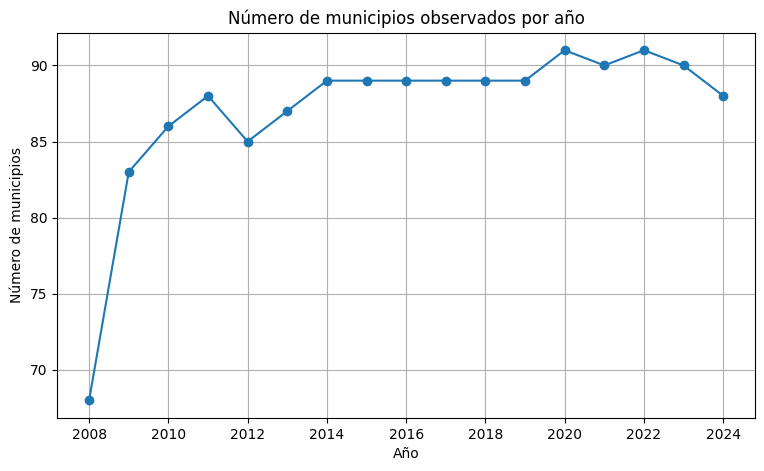

In [53]:
# =========================
# Cobertura temporal
# =========================

cobertura_anual = (
    df_eda
    .groupby(time_col)
    .agg(
        n_municipios=("Municipio", "nunique"),
        n_obs=(target_col, "size"),
        rendimiento_promedio=(target_col, "mean"),
        rendimiento_mediana=(target_col, "median")
    )
    .reset_index()
)

display(cobertura_anual)

plt.figure(figsize=(9, 5))
plt.plot(cobertura_anual[time_col], cobertura_anual["n_municipios"], marker="o")
plt.xlabel("Año")
plt.ylabel("Número de municipios")
plt.title("Número de municipios observados por año")
plt.grid(True)
plt.show()

count    1481.000000
mean        0.929723
std         0.290802
min         0.064259
25%         0.736490
50%         0.962962
75%         1.119972
max         1.943144
Name: Rendimiento, dtype: float64

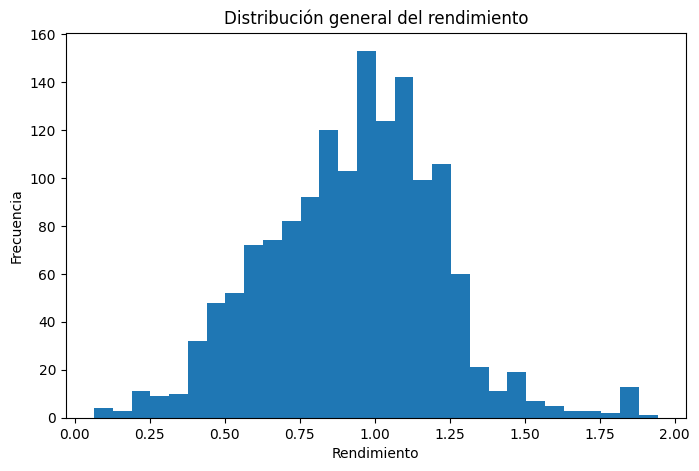

In [54]:
#Estadísticos del target

display(df_eda[target_col].describe())

plt.figure(figsize=(8, 5))
plt.hist(df_eda[target_col].dropna(), bins=30)
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")
plt.title("Distribución general del rendimiento")
plt.show()

In [55]:
# Posibles outliers del rendimiento

q1 = df_eda[target_col].quantile(0.25)
q3 = df_eda[target_col].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_rend = df_eda[
    (df_eda[target_col] < lim_inf) |
    (df_eda[target_col] > lim_sup)
].copy()

print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)
print("Outliers detectados:", outliers_rend.shape[0])

display(outliers_rend[id_cols + [time_col, target_col]].sort_values(target_col))

Límite inferior: 0.16126646621108043
Límite superior: 1.695195110780984
Outliers detectados: 26


,Departamento,Municipio,Año,Rendimiento
737,CUNDINAMARCA,SILVANIA,2011,0.064259
1041,NARINO,CUMBITARA,2022,0.069796
264,CUNDINAMARCA,GACHALA,2008,0.092868
1364,NARINO,SAMANIEGO,2022,0.110551
680,CUNDINAMARCA,SAN CAYETANO,2022,0.128389
281,CUNDINAMARCA,GACHETA,2008,0.136201
599,CUNDINAMARCA,PASCA,2024,0.153231
749,CUNDINAMARCA,SILVANIA,2023,1.722069
358,CUNDINAMARCA,GUAYABETAL,2018,1.723765
877,CUNDINAMARCA,VILLAGOMEZ,2018,1.723768


,Año,rendimiento_mean,rendimiento_median,rendimiento_std,n_obs
0,2008,0.835642,0.831619,0.345518,68
1,2009,0.830293,0.824096,0.293222,83
2,2010,0.847526,0.844785,0.298294,86
3,2011,0.863672,0.891892,0.283310,88
4,2012,0.797604,0.800000,0.258922,85
5,2013,0.700264,0.641245,0.211233,87
6,2014,0.759174,0.693372,0.226196,89
7,2015,0.973825,1.001014,0.119762,89
8,2016,1.007131,1.035249,0.123858,89
9,2017,1.051270,1.011203,0.278976,89


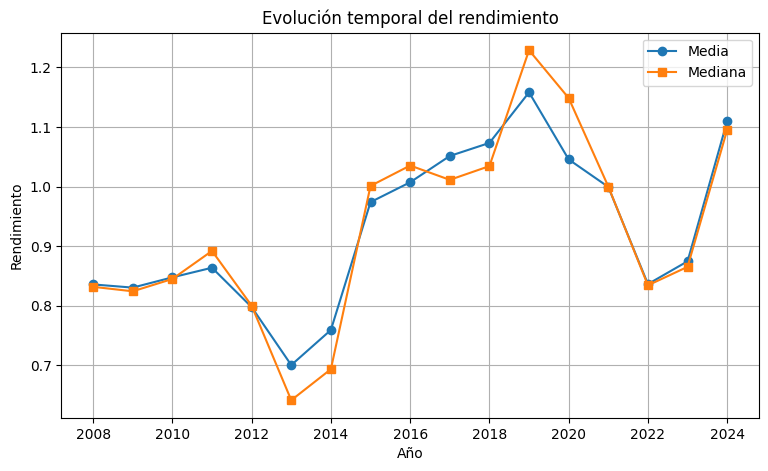

In [ ]:
# Rendimiento promedio anual

rend_anual = (
    df_eda
    .groupby(time_col)
    .agg(
        rendimiento_mean=(target_col, "mean"),
        rendimiento_median=(target_col, "median"),
        rendimiento_std=(target_col, "std"),
        n_obs=(target_col, "size")
    )
    .reset_index()
)

display(rend_anual)

plt.figure(figsize=(9, 5))
plt.plot(rend_anual[time_col], rend_anual["rendimiento_mean"], marker="o", label="Media")
plt.plot(rend_anual[time_col], rend_anual["rendimiento_median"], marker="s", label="Mediana")
plt.xlabel("Año")
plt.ylabel("Rendimiento")
plt.title("Evolución temporal del rendimiento")
plt.legend()
plt.grid(True)
plt.show()

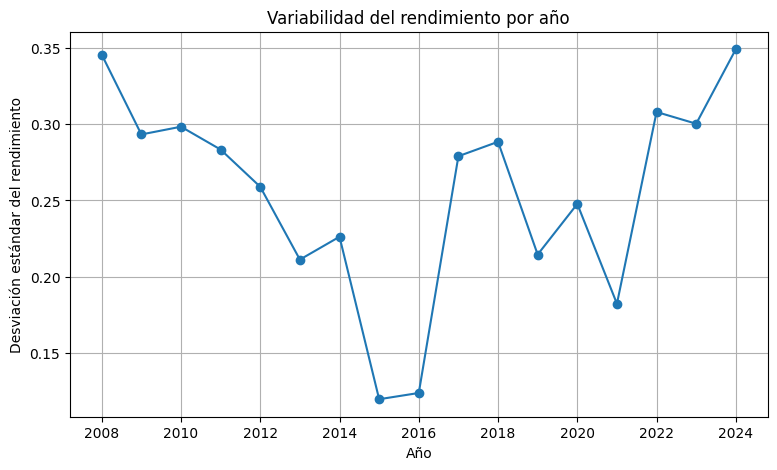

In [57]:
plt.figure(figsize=(9, 5))
plt.plot(rend_anual[time_col], rend_anual["rendimiento_std"], marker="o")
plt.xlabel("Año")
plt.ylabel("Desviación estándar del rendimiento")
plt.title("Variabilidad del rendimiento por año")
plt.grid(True)
plt.show()

In [58]:
# Heterogeneidad municipal


rend_mun = (
    df_eda
    .groupby(id_cols)
    .agg(
        rendimiento_mean=(target_col, "mean"),
        rendimiento_median=(target_col, "median"),
        rendimiento_std=(target_col, "std"),
        rendimiento_min=(target_col, "min"),
        rendimiento_max=(target_col, "max"),
        n_anios=(time_col, "nunique")
    )
    .reset_index()
)

display(rend_mun.sort_values("rendimiento_mean", ascending=False))

,Departamento,Municipio,rendimiento_mean,rendimiento_median,rendimiento_std,rendimiento_min,rendimiento_max,n_anios
44,CUNDINAMARCA,SASAIMA,1.223064,1.132835,0.368751,0.705368,1.865058,17
71,NARINO,IPIALES,1.200000,1.200000,0.000000,1.200000,1.200000,2
21,CUNDINAMARCA,GUAYABETAL,1.197500,1.176102,0.259104,0.792352,1.723765,16
80,NARINO,PASTO,1.177489,1.200000,0.331365,0.600000,1.856593,17
32,CUNDINAMARCA,PACHO,1.160195,1.139777,0.232780,0.897743,1.819458,16
...,...,...,...,...,...,...,...,...
24,CUNDINAMARCA,JUNIN,0.698382,0.740785,0.191288,0.431865,1.084458,16
20,CUNDINAMARCA,GUAYABAL DE SIQUIMA,0.688070,0.606544,0.254795,0.343396,1.237719,17
2,CUNDINAMARCA,APULO,0.682839,0.693371,0.266699,0.209312,1.139535,17
17,CUNDINAMARCA,GACHETA,0.679505,0.690007,0.319528,0.136201,1.435756,17


In [59]:
top_mun = rend_mun.sort_values("rendimiento_mean", ascending=False).head(10)
bottom_mun = rend_mun.sort_values("rendimiento_mean", ascending=True).head(10)

display(top_mun)
display(bottom_mun)

,Departamento,Municipio,rendimiento_mean,rendimiento_median,rendimiento_std,rendimiento_min,rendimiento_max,n_anios
44,CUNDINAMARCA,SASAIMA,1.223064,1.132835,0.368751,0.705368,1.865058,17
71,NARINO,IPIALES,1.200000,1.200000,0.000000,1.200000,1.200000,2
21,CUNDINAMARCA,GUAYABETAL,1.197500,1.176102,0.259104,0.792352,1.723765,16
80,NARINO,PASTO,1.177489,1.200000,0.331365,0.600000,1.856593,17
32,CUNDINAMARCA,PACHO,1.160195,1.139777,0.232780,0.897743,1.819458,16
73,NARINO,LA FLORIDA,1.149396,1.162122,0.177013,0.700000,1.465199,17
8,CUNDINAMARCA,CAQUEZA,1.146568,1.156499,0.165421,0.750000,1.386737,16
86,NARINO,SAN PABLO,1.136196,1.140398,0.162203,0.900000,1.520004,17
75,NARINO,LA UNION,1.128436,1.131465,0.178254,0.850794,1.650000,17
85,NARINO,SAN LORENZO,1.122850,1.132733,0.138696,0.870134,1.300000,17


,Departamento,Municipio,rendimiento_mean,rendimiento_median,rendimiento_std,rendimiento_min,rendimiento_max,n_anios
62,NARINO,CUMBAL,0.554444,0.600000,0.149759,0.300000,0.700000,9
17,CUNDINAMARCA,GACHETA,0.679505,0.690007,0.319528,0.136201,1.435756,17
2,CUNDINAMARCA,APULO,0.682839,0.693371,0.266699,0.209312,1.139535,17
20,CUNDINAMARCA,GUAYABAL DE SIQUIMA,0.688070,0.606544,0.254795,0.343396,1.237719,17
24,CUNDINAMARCA,JUNIN,0.698382,0.740785,0.191288,0.431865,1.084458,16
18,CUNDINAMARCA,GAMA,0.702173,0.786472,0.211265,0.290145,0.985915,17
36,CUNDINAMARCA,PASCA,0.717588,0.693374,0.252493,0.153231,1.034262,15
15,CUNDINAMARCA,FUSAGASUGA,0.741021,0.776323,0.171908,0.499582,1.126394,17
47,CUNDINAMARCA,TIBACUY,0.753502,0.756736,0.214449,0.450000,1.152439,17
57,CUNDINAMARCA,ZIPACON,0.765634,0.727974,0.166877,0.577120,1.113870,17


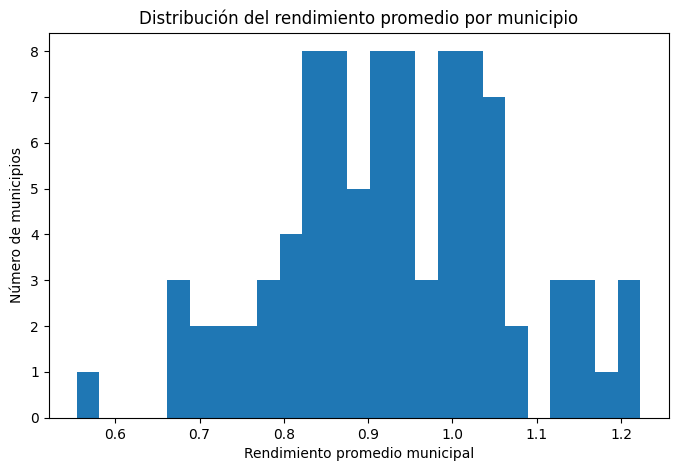

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(rend_mun["rendimiento_mean"].dropna(), bins=25)
plt.xlabel("Rendimiento promedio municipal")
plt.ylabel("Número de municipios")
plt.title("Distribución del rendimiento promedio por municipio")
plt.show()

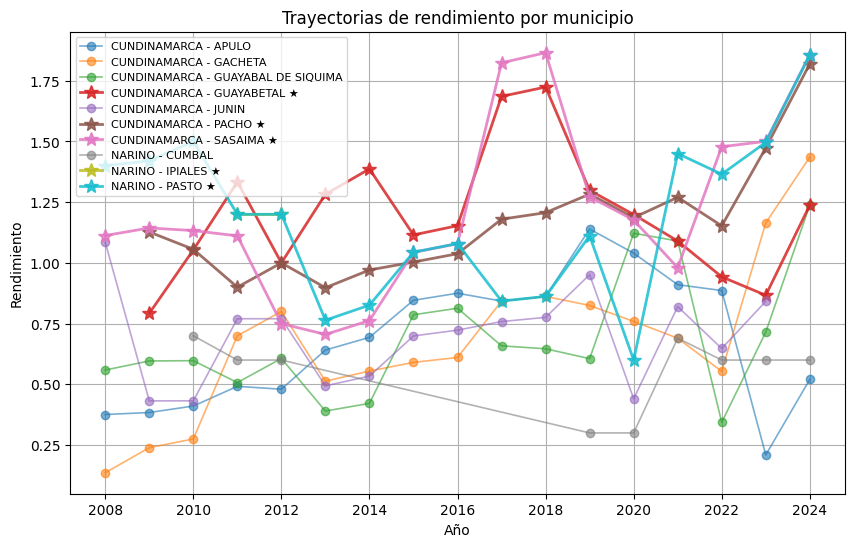

In [ ]:
# Trayectorias de municipios
# Rendimiento medio por municipio (o por el id que corresponda)
rend_medio = (
    df_eda
    .groupby(id_cols)["Rendimiento"]
    .mean()
    .reset_index()
    .sort_values("Rendimiento")
)

municipios_muestra = pd.concat([
    rend_medio.head(5),   # los 5 con menor rendimiento medio
    rend_medio.tail(5),   # los 5 con mayor rendimiento medio
])[id_cols].drop_duplicates().reset_index(drop=True)
df_muestra = df_eda.merge(municipios_muestra, on=id_cols, how="inner")

plt.figure(figsize=(10, 6))

for keys, g in df_muestra.groupby(id_cols):
    label = f"{keys[0]} - {keys[1]}"
    is_top5 = keys in set(map(tuple, rend_medio.tail(5)[id_cols].values))
    plt.plot(
        g[time_col], g[target_col],
        marker="*" if is_top5 else "o",
        markersize=10 if is_top5 else 6,
        linewidth=2 if is_top5 else 1.2,
        alpha=0.85 if is_top5 else 0.6,
        label=label + (" ★" if is_top5 else ""),
    )

plt.xlabel("Año")
plt.ylabel("Rendimiento")
plt.title("Trayectorias de rendimiento por municipio")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [63]:
# Variación between y within


media_global = df_eda[target_col].mean()

media_por_mun = df_eda.groupby(id_cols)[target_col].transform("mean")
media_por_anio = df_eda.groupby(time_col)[target_col].transform("mean")

df_eda["rendimiento_within_mun"] = df_eda[target_col] - media_por_mun
df_eda["rendimiento_between_mun"] = media_por_mun - media_global
df_eda["rendimiento_efecto_anio"] = media_por_anio - media_global

var_total = df_eda[target_col].var()
var_within = df_eda["rendimiento_within_mun"].var()
var_between = df_eda[["Departamento", "Municipio", "rendimiento_between_mun"]].drop_duplicates()["rendimiento_between_mun"].var()

resumen_var = pd.DataFrame({
    "componente": ["Varianza total", "Varianza within municipio", "Varianza between municipio"],
    "valor": [var_total, var_within, var_between],
    "porcentaje_vs_total": [
        100,
        100 * var_within / var_total,
        100 * var_between / var_total
    ]
})

display(resumen_var)

,componente,valor,porcentaje_vs_total
0,Varianza total,0.084566,100.000000
1,Varianza within municipio,0.067692,80.046165
2,Varianza between municipio,0.018097,21.399553


In [64]:
# Target futuro
# =========================

grupo = df_eda.groupby(id_cols)

df_eda["rendimiento_t1"] = grupo[target_col].shift(-1)
df_eda["anio_t1"] = grupo[time_col].shift(-1)

# Validar continuidad: el futuro debe ser exactamente t+1
df_eda.loc[df_eda["anio_t1"] != df_eda[time_col] + 1, "rendimiento_t1"] = np.nan

print("Filas con target futuro válido:", df_eda["rendimiento_t1"].notna().sum())

Filas con target futuro válido: 1376


Correlación rendimiento_t vs rendimiento_t+1: 0.592


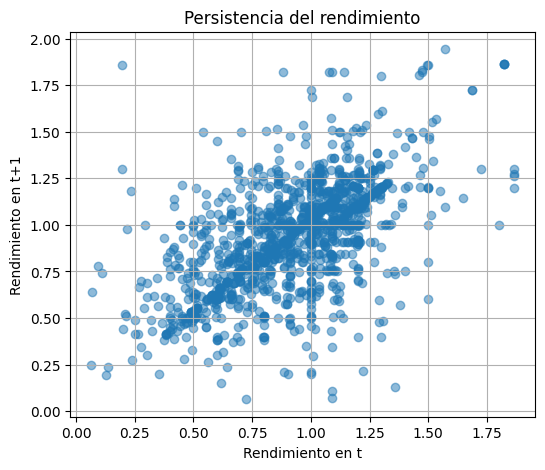

In [65]:
# Persistencia temporal
# =========================

df_pred = df_eda.dropna(subset=[target_col, "rendimiento_t1"]).copy()

corr_actual_futuro = df_pred[[target_col, "rendimiento_t1"]].corr().iloc[0, 1]

print("Correlación rendimiento_t vs rendimiento_t+1:", round(corr_actual_futuro, 3))

plt.figure(figsize=(6, 5))
plt.scatter(df_pred[target_col], df_pred["rendimiento_t1"], alpha=0.5)
plt.xlabel("Rendimiento en t")
plt.ylabel("Rendimiento en t+1")
plt.title("Persistencia del rendimiento")
plt.grid(True)
plt.show()

,lag,correlacion,n_obs
0,rendimiento_lag1,0.591598,1376
1,rendimiento_lag2,0.315474,1273
2,rendimiento_lag3,0.182631,1172


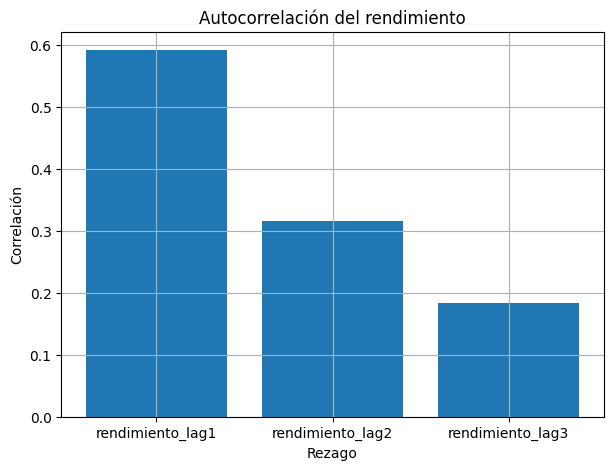

In [67]:
# Rezagos del target
# =========================

df_eda["rendimiento_lag1"] = grupo[target_col].shift(1)
df_eda["rendimiento_lag2"] = grupo[target_col].shift(2)
df_eda["rendimiento_lag3"] = grupo[target_col].shift(3)

df_eda["diff_anio_1"] = grupo[time_col].diff(1)
df_eda["diff_anio_2"] = grupo[time_col].diff(2)
df_eda["diff_anio_3"] = grupo[time_col].diff(3)

df_eda.loc[df_eda["diff_anio_1"] != 1, "rendimiento_lag1"] = np.nan
df_eda.loc[df_eda["diff_anio_2"] != 2, "rendimiento_lag2"] = np.nan
df_eda.loc[df_eda["diff_anio_3"] != 3, "rendimiento_lag3"] = np.nan

lags = ["rendimiento_lag1", "rendimiento_lag2", "rendimiento_lag3"]

autocorrs = []

for lag in lags:
    temp = df_eda.dropna(subset=[target_col, lag])
    autocorrs.append({
        "lag": lag,
        "correlacion": temp[[target_col, lag]].corr().iloc[0, 1],
        "n_obs": temp.shape[0]
    })

autocorrs = pd.DataFrame(autocorrs)

display(autocorrs)
plt.figure(figsize=(7, 5))
plt.bar(autocorrs["lag"], autocorrs["correlacion"])
plt.xlabel("Rezago")
plt.ylabel("Correlación")
plt.title("Autocorrelación del rendimiento")
plt.grid(True)
plt.show()

,corr_con_rendimiento_t1
Rendimiento,0.591598
rendimiento_between_mun,0.439513
rendimiento_within_mun,0.437564
rendimiento_lag1,0.315474
rendimiento_efecto_anio,0.310729
log1p_radiación solar acumulada anual (mj/m²/año),0.266942
SPI3_floracion,-0.249376
Año,0.241814
SPI1_floracion,-0.208126
SPI12_mean_anual,-0.187938


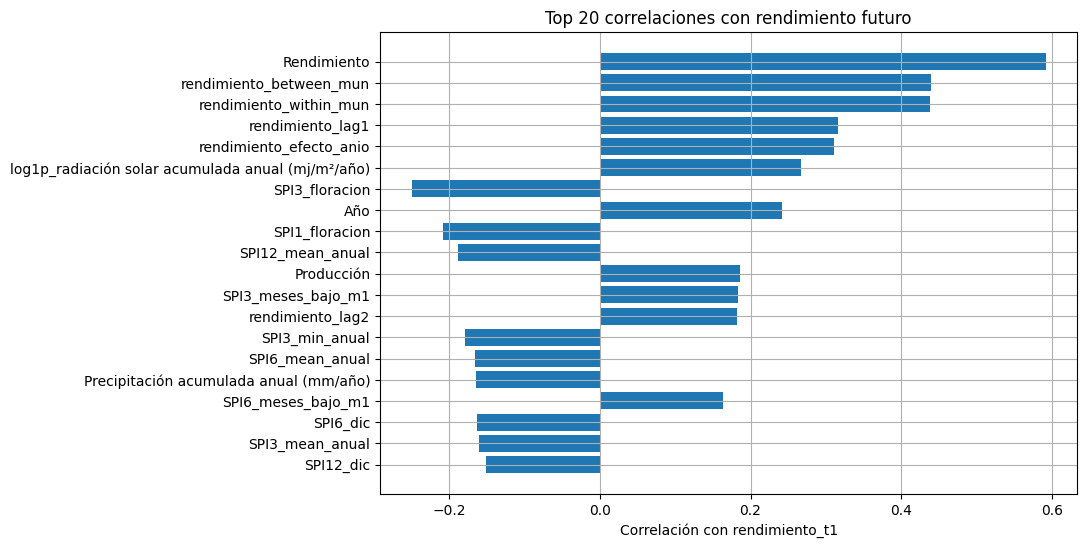

In [68]:
# Correlaciones con rendimiento_t1
# =========================

df_corr = df_eda.dropna(subset=["rendimiento_t1"]).copy()

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

cols_excluir = [
    "rendimiento_t1",
    "anio_t1"
]

numeric_features = [
    c for c in numeric_cols
    if c not in cols_excluir
]

corr_target = (
    df_corr[numeric_features + ["rendimiento_t1"]]
    .corr()["rendimiento_t1"]
    .drop("rendimiento_t1")
    .sort_values(key=abs, ascending=False)
)

display(corr_target.to_frame("corr_con_rendimiento_t1").head(30))

top_corr = corr_target.head(20)

plt.figure(figsize=(9, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.xlabel("Correlación con rendimiento_t1")
plt.title("Top 20 correlaciones con rendimiento futuro")
plt.grid(True)
plt.show()

In [69]:
# Pares altamente correlacionados
# =========================

corr_matrix = df_eda[numeric_features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pares_corr_altos = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "variable_1",
        "level_1": "variable_2",
        0: "correlacion_abs"
    })
    .sort_values("correlacion_abs", ascending=False)
)

display(pares_corr_altos[pares_corr_altos["correlacion_abs"] >= 0.90].head(50))

,variable_1,variable_2,correlacion_abs
147,Temperatura media anual (°C),Mínimo de la temperatura media mensual (°C),0.995579
146,Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),0.993915
276,Humedad volumétrica media anual del suelo capa...,Humedad volumétrica media anual del suelo capa...,0.993384
180,Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),0.983380
365,SPI3_mean_anual,SPI6_mean_anual,0.969036
233,Mínimo de la temperatura media mensual (°C),altitud_media_m,0.948165
168,Temperatura media anual (°C),altitud_media_m,0.947183
373,SPI3_mean_anual,SPI12_dic,0.935706
201,Máximo de la temperatura media mensual (°C),altitud_media_m,0.935484
510,SPI12_mean_anual,SPI12_min_anual,0.926821


In [78]:
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1376 entries, 0 to 1479
Data columns (total 43 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Departamento                                              1376 non-null   object 
 1   Municipio                                                 1376 non-null   object 
 2   Año                                                       1376 non-null   int64  
 3   Producción                                                1376 non-null   float64
 4   Rendimiento                                               1376 non-null   float64
 5   Precipitación acumulada anual (mm/año)                    1376 non-null   float64
 6   Temperatura media anual (°C)                              1376 non-null   float64
 7   Máximo de la temperatura media mensual (°C)               1376 non-null   float64
 8   Mínimo de la temperatur

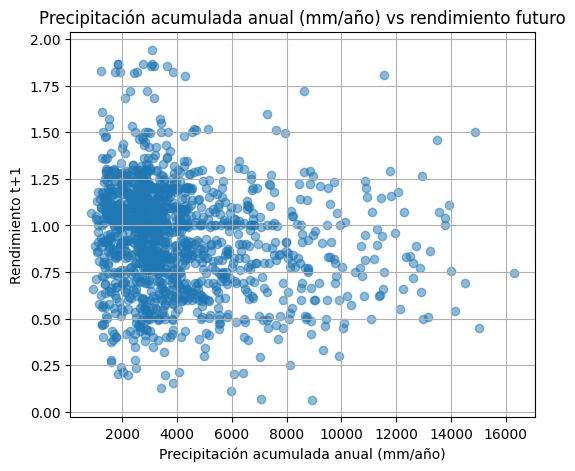

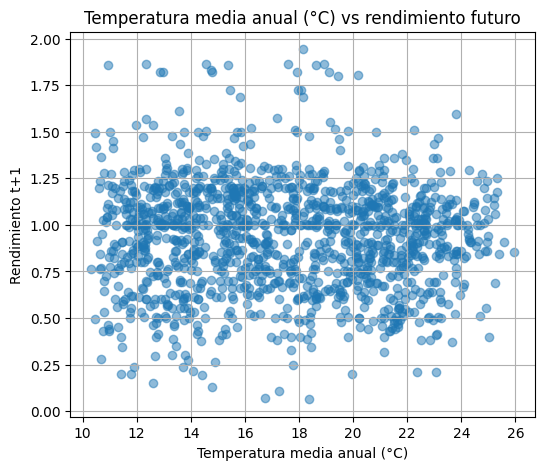

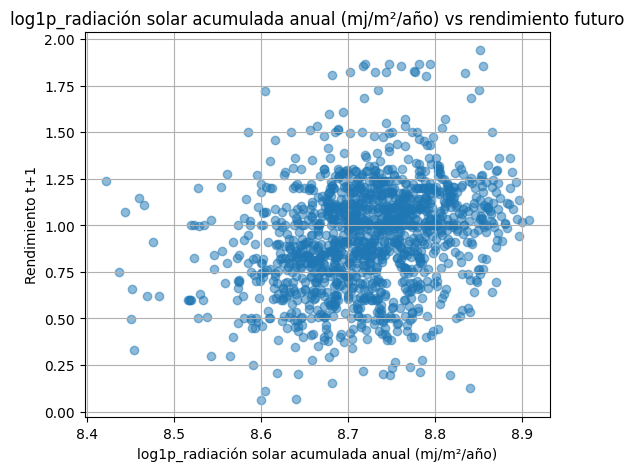

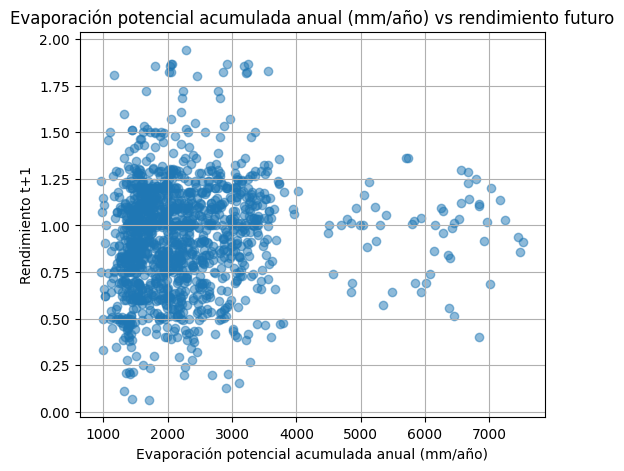

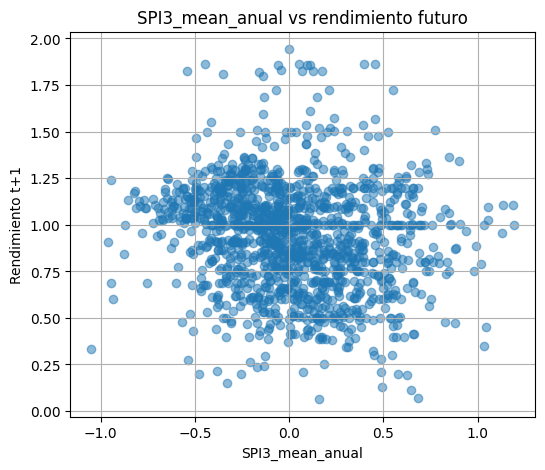

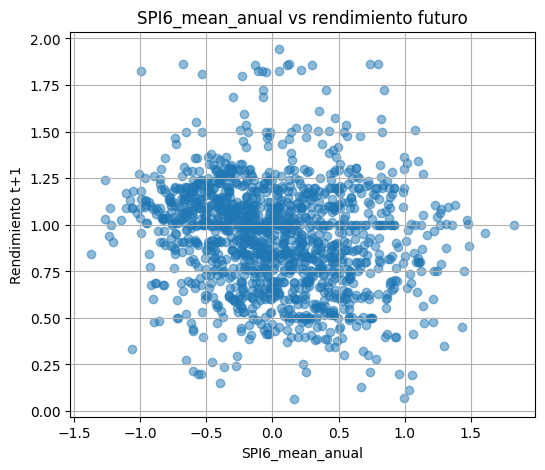

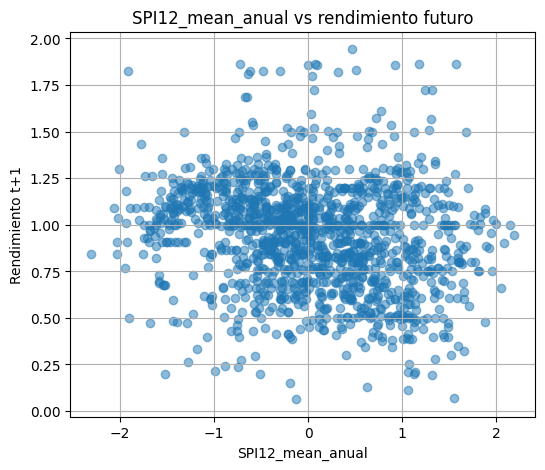

In [79]:
vars_clima = [
    "Precipitación acumulada anual (mm/año)",
    "Temperatura media anual (°C)",
    "log1p_radiación solar acumulada anual (mj/m²/año)",
    "Evaporación potencial acumulada anual (mm/año)",
    "SPI3_mean_anual",
    "SPI6_mean_anual",
    "SPI12_mean_anual"
]

for var in vars_clima:
    if var in df_corr.columns:
        plt.figure(figsize=(6, 5))
        plt.scatter(df_corr[var], df_corr["rendimiento_t1"], alpha=0.5)
        plt.xlabel(var)
        plt.ylabel("Rendimiento t+1")
        plt.title(f"{var} vs rendimiento futuro")
        plt.grid(True)
        plt.show()

C:\Users\ramires7\AppData\Local\Temp\ipykernel_34972\368281893.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=years, showfliers=True)


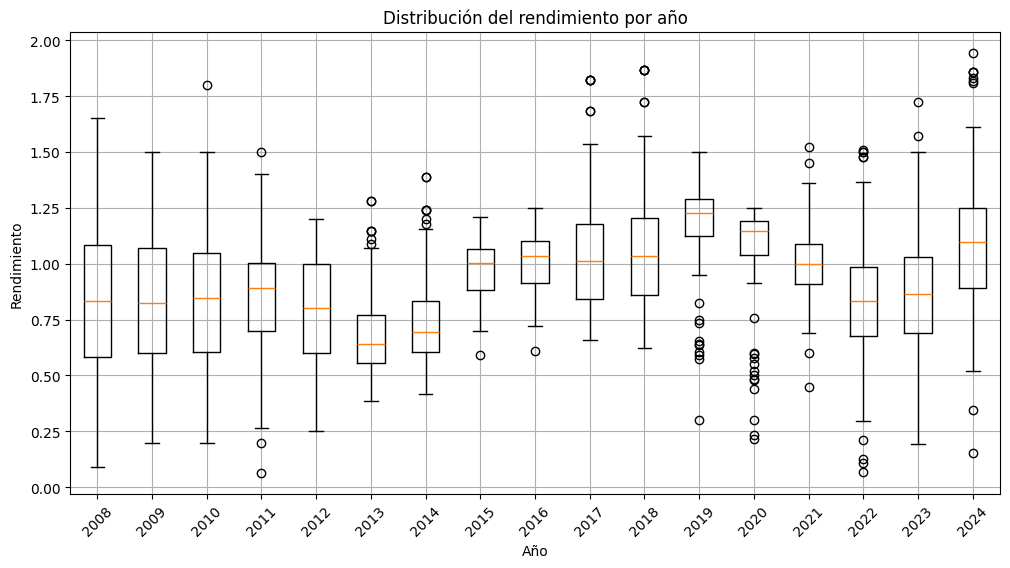

In [71]:
# Boxplot anual del rendimiento
# =========================

years = sorted(df_eda[time_col].dropna().unique())

data_box = [
    df_eda.loc[df_eda[time_col] == year, target_col].dropna()
    for year in years
]

plt.figure(figsize=(12, 6))
plt.boxplot(data_box, labels=years, showfliers=True)
plt.xlabel("Año")
plt.ylabel("Rendimiento")
plt.title("Distribución del rendimiento por año")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [72]:
# =========================
# Resumen general del panel
# =========================

resumen_eda = pd.DataFrame({
    "indicador": [
        "Número de filas",
        "Número de columnas",
        "Número de años",
        "Año mínimo",
        "Año máximo",
        "Número de municipios",
        "Nulos en rendimiento",
        "Rendimiento promedio",
        "Rendimiento mediano",
        "Rendimiento mínimo",
        "Rendimiento máximo",
        "Desviación estándar rendimiento",
        "Filas con target futuro válido",
        "Duplicados municipio-año"
    ],
    "valor": [
        df_eda.shape[0],
        df_eda.shape[1],
        df_eda[time_col].nunique(),
        df_eda[time_col].min(),
        df_eda[time_col].max(),
        df_eda[id_cols].drop_duplicates().shape[0],
        df_eda[target_col].isna().sum(),
        df_eda[target_col].mean(),
        df_eda[target_col].median(),
        df_eda[target_col].min(),
        df_eda[target_col].max(),
        df_eda[target_col].std(),
        df_eda["rendimiento_t1"].notna().sum(),
        df_eda.duplicated(subset=id_cols + [time_col]).sum()
    ]
})

display(resumen_eda)

,indicador,valor
0,Número de filas,1481.000000
1,Número de columnas,43.000000
2,Número de años,17.000000
3,Año mínimo,2008.000000
4,Año máximo,2024.000000
5,Número de municipios,92.000000
6,Nulos en rendimiento,0.000000
7,Rendimiento promedio,0.929723
8,Rendimiento mediano,0.962962
9,Rendimiento mínimo,0.064259


## Pruebas estadisticas

In [ ]:
df_panel = df_final.copy()

id_cols = ["Departamento", "Municipio"]
time_col = "Año"
target_col = "Rendimiento"

df_panel = df_panel.sort_values(id_cols + [time_col]).reset_index(drop=True)

df_panel["id_panel"] = (
    df_panel["Departamento"].astype(str).str.strip()
    + " - "
    + df_panel["Municipio"].astype(str).str.strip()
)

In [ ]:
# Validación de llave panel


duplicados_panel = (
    df_panel[df_panel.duplicated(subset=["id_panel", time_col], keep=False)]
    .sort_values(["id_panel", time_col])
)

print("Duplicados municipio-año:", duplicados_panel.shape[0])
display(duplicados_panel.head(30))

Duplicados municipio-año: 0


,Departamento,Municipio,Año,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad relativa media anual (%),...,SPI6_dic,SPI12_dic,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,log1p_área sembrada,log1p_radiación solar acumulada anual (mj/m²/año),id_panel


In [83]:
resumen_panel = pd.DataFrame({
    "indicador": [
        "Filas",
        "Columnas",
        "Municipios",
        "Años",
        "Año mínimo",
        "Año máximo",
        "Duplicados municipio-año",
        "Nulos en target"
    ],
    "valor": [
        df_panel.shape[0],
        df_panel.shape[1],
        df_panel["id_panel"].nunique(),
        df_panel[time_col].nunique(),
        df_panel[time_col].min(),
        df_panel[time_col].max(),
        df_panel.duplicated(subset=["id_panel", time_col]).sum(),
        df_panel[target_col].isna().sum()
    ]
})

display(resumen_panel)

,indicador,valor
0,Filas,1481
1,Columnas,33
2,Municipios,92
3,Años,17
4,Año mínimo,2008
5,Año máximo,2024
6,Duplicados municipio-año,0
7,Nulos en target,0


#### Saltos temporales

,id_panel,anio_min,anio_max,n_anios,n_obs,anios_esperados,panel_completo_interno
71,NARINO - IPIALES,2011,2012,2,2,2,True
62,NARINO - CUMBAL,2010,2024,9,9,15,False
69,NARINO - ILES,2014,2024,11,11,11,True
74,NARINO - LA LLANADA,2008,2024,11,11,17,False
91,NARINO - TUQUERRES,2013,2024,12,12,12,True
...,...,...,...,...,...,...,...
82,NARINO - PROVIDENCIA,2008,2024,17,17,17,True
87,NARINO - SANDONA,2008,2024,17,17,17,True
88,NARINO - SANTACRUZ,2008,2024,17,17,17,True
89,NARINO - TAMINANGO,2008,2024,17,17,17,True


Municipios con serie continua interna:
panel_completo_interno
True     79
False    13
Name: count, dtype: int64


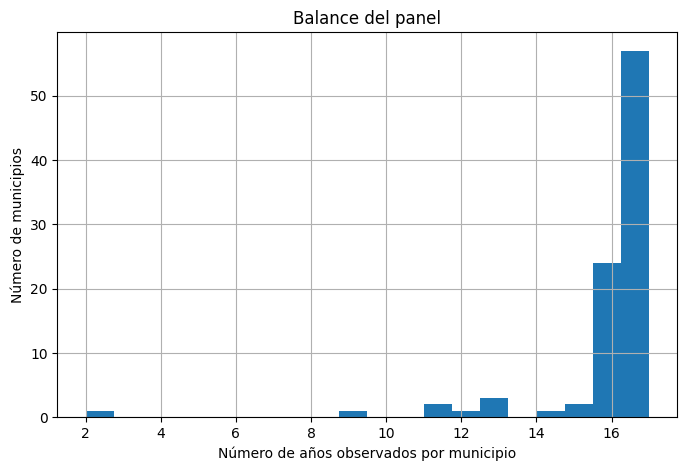

In [84]:
# =========================
# Balance del panel
# =========================

balance_panel = (
    df_panel
    .groupby("id_panel")
    .agg(
        anio_min=(time_col, "min"),
        anio_max=(time_col, "max"),
        n_anios=(time_col, "nunique"),
        n_obs=(target_col, "size")
    )
    .reset_index()
)

balance_panel["anios_esperados"] = (
    balance_panel["anio_max"] - balance_panel["anio_min"] + 1
)

balance_panel["panel_completo_interno"] = (
    balance_panel["n_anios"] == balance_panel["anios_esperados"]
)

display(balance_panel.sort_values("n_anios"))

print("Municipios con serie continua interna:")
print(balance_panel["panel_completo_interno"].value_counts())

plt.figure(figsize=(8, 5))
plt.hist(balance_panel["n_anios"], bins=20)
plt.xlabel("Número de años observados por municipio")
plt.ylabel("Número de municipios")
plt.title("Balance del panel")
plt.grid(True)
plt.show()

In [ ]:
# Saltos temporales por municipio


df_panel["diff_anio"] = df_panel.groupby("id_panel")[time_col].diff()

saltos_temporales = df_panel[
    (df_panel["diff_anio"].notna()) & 
    (df_panel["diff_anio"] != 1)
].copy()

print("Saltos temporales encontrados:", saltos_temporales.shape[0])

display(
    saltos_temporales[
        ["id_panel", time_col, "diff_anio", target_col]
    ].sort_values(["id_panel", time_col])
)

Saltos temporales encontrados: 13


,id_panel,Año,diff_anio,Rendimiento
13,CUNDINAMARCA - ANAPOIMA,2022,2.0,1.166099
138,CUNDINAMARCA - CAQUEZA,2012,2.0,0.750000
169,CUNDINAMARCA - CHOACHI,2013,2.0,0.490218
196,CUNDINAMARCA - EL COLEGIO,2024,2.0,1.610004
367,CUNDINAMARCA - GUTIERREZ,2013,2.0,0.961867
588,CUNDINAMARCA - PASCA,2013,2.0,0.641246
654,CUNDINAMARCA - SAN BERNARDO,2013,2.0,0.641244
878,CUNDINAMARCA - VILLAGOMEZ,2020,2.0,1.165138
955,NARINO - ARBOLEDA,2013,2.0,0.611205
1021,NARINO - CUMBAL,2019,7.0,0.300000


In [86]:
# Target futuro validando continuidad


grupo = df_panel.groupby("id_panel")

df_panel["rendimiento_t1"] = grupo[target_col].shift(-1)
df_panel["anio_t1"] = grupo[time_col].shift(-1)

# Validar que el siguiente periodo sea exactamente t + 1
df_panel.loc[
    df_panel["anio_t1"] != df_panel[time_col] + 1,
    "rendimiento_t1"
] = np.nan

print("Filas con rendimiento futuro válido:", df_panel["rendimiento_t1"].notna().sum())
print("Filas sin rendimiento futuro válido:", df_panel["rendimiento_t1"].isna().sum())

Filas con rendimiento futuro válido: 1376
Filas sin rendimiento futuro válido: 105


In [ ]:
# Rezagos seguros del target


df_panel["rendimiento_lag1"] = grupo[target_col].shift(1)
df_panel["rendimiento_lag2"] = grupo[target_col].shift(2)
df_panel["rendimiento_lag3"] = grupo[target_col].shift(3)

df_panel["diff_lag1"] = grupo[time_col].diff(1)
df_panel["diff_lag2"] = grupo[time_col].diff(2)
df_panel["diff_lag3"] = grupo[time_col].diff(3)

df_panel.loc[df_panel["diff_lag1"] != 1, "rendimiento_lag1"] = np.nan
df_panel.loc[df_panel["diff_lag2"] != 2, "rendimiento_lag2"] = np.nan
df_panel.loc[df_panel["diff_lag3"] != 3, "rendimiento_lag3"] = np.nan

Correlación rendimiento_t vs rendimiento_t+1: 0.5916


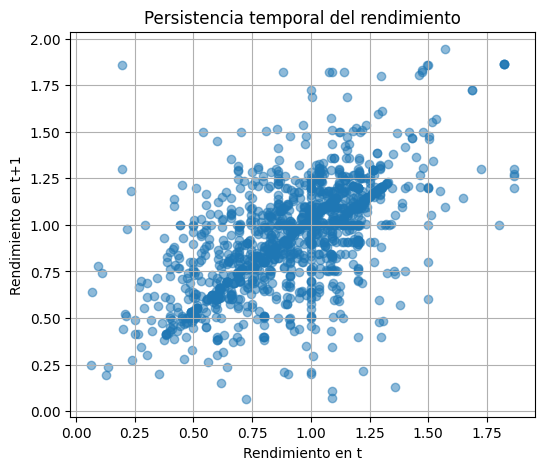

In [89]:
# =========================
# Correlación target actual vs target futuro
# =========================

df_temp = df_panel.dropna(subset=[target_col, "rendimiento_t1"]).copy()

corr_t_t1 = df_temp[[target_col, "rendimiento_t1"]].corr().iloc[0, 1]

print("Correlación rendimiento_t vs rendimiento_t+1:", round(corr_t_t1, 4))

plt.figure(figsize=(6, 5))
plt.scatter(df_temp[target_col], df_temp["rendimiento_t1"], alpha=0.5)
plt.xlabel("Rendimiento en t")
plt.ylabel("Rendimiento en t+1")
plt.title("Persistencia temporal del rendimiento")
plt.grid(True)
plt.show()

In [92]:
# =========================
# ADF por municipio
# =========================

def prueba_adf_por_panel(df, id_col, time_col, target_col, min_obs=8):
    resultados = []

    for entidad, g in df.groupby(id_col):
        g = g.sort_values(time_col)
        serie = g[target_col].dropna()

        if serie.shape[0] < min_obs:
            resultados.append({
                "id_panel": entidad,
                "n_obs": serie.shape[0],
                "adf_stat": np.nan,
                "p_value": np.nan,
                "resultado": "No evaluado: pocas observaciones"
            })
            continue

        try:
            stat, pvalue, usedlag, nobs, crit, icbest = adfuller(
                serie,
                autolag="AIC"
            )

            if pvalue < 0.05:
                resultado = "Estacionaria al 5%"
            else:
                resultado = "No estacionaria al 5%"

            resultados.append({
                "id_panel": entidad,
                "n_obs": serie.shape[0],
                "adf_stat": stat,
                "p_value": pvalue,
                "used_lag": usedlag,
                "resultado": resultado
            })

        except Exception as e:
            resultados.append({
                "id_panel": entidad,
                "n_obs": serie.shape[0],
                "adf_stat": np.nan,
                "p_value": np.nan,
                "resultado": f"Error: {e}"
            })

    return pd.DataFrame(resultados)

adf_resultados = prueba_adf_por_panel(
    df_panel,
    id_col="id_panel",
    time_col=time_col,
    target_col=target_col,
    min_obs=8
)

display(adf_resultados)

resumen_adf = (
    adf_resultados["resultado"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "resultado", "resultado": "conteo"})
)

display(resumen_adf)

,id_panel,n_obs,adf_stat,p_value,used_lag,resultado
0,CUNDINAMARCA - ANAPOIMA,16,2.471638,9.990401e-01,6.0,No estacionaria al 5%
1,CUNDINAMARCA - ANOLAIMA,17,-2.059809,2.609794e-01,1.0,No estacionaria al 5%
2,CUNDINAMARCA - APULO,17,-2.666042,8.010112e-02,6.0,No estacionaria al 5%
3,CUNDINAMARCA - ARBELAEZ,17,-6.449359,1.537197e-08,6.0,Estacionaria al 5%
4,CUNDINAMARCA - BELTRAN,17,-8.858935,1.501178e-14,6.0,Estacionaria al 5%
...,...,...,...,...,...,...
87,NARINO - SANDONA,17,-3.128049,2.454586e-02,3.0,Estacionaria al 5%
88,NARINO - SANTACRUZ,17,-3.095786,2.686665e-02,6.0,Estacionaria al 5%
89,NARINO - TAMINANGO,17,-3.200468,1.995763e-02,2.0,Estacionaria al 5%
90,NARINO - TANGUA,17,-11.523957,3.977669e-21,6.0,Estacionaria al 5%


,conteo,count
0,No estacionaria al 5%,60
1,Estacionaria al 5%,31
2,No evaluado: pocas observaciones,1


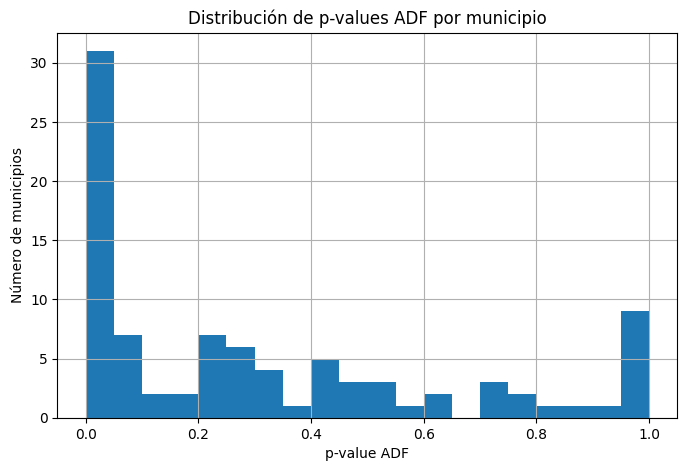

In [93]:
plt.figure(figsize=(8, 5))
plt.hist(adf_resultados["p_value"].dropna(), bins=20)
plt.xlabel("p-value ADF")
plt.ylabel("Número de municipios")
plt.title("Distribución de p-values ADF por municipio")
plt.grid(True)
plt.show()

In [103]:
# =========================
# Mostrar p-values con máximo 3 decimales
# =========================

adf_resultados_display = adf_resultados.copy()

adf_resultados_display["p_value"] = adf_resultados_display["p_value"].round(3)
adf_resultados_display["adf_stat"] = adf_resultados_display["adf_stat"].round(3)

display(adf_resultados_display)

,id_panel,n_obs,adf_stat,p_value,used_lag,resultado
0,CUNDINAMARCA - ANAPOIMA,16,2.472,0.999,6.0,No estacionaria al 5%
1,CUNDINAMARCA - ANOLAIMA,17,-2.060,0.261,1.0,No estacionaria al 5%
2,CUNDINAMARCA - APULO,17,-2.666,0.080,6.0,No estacionaria al 5%
3,CUNDINAMARCA - ARBELAEZ,17,-6.449,0.000,6.0,Estacionaria al 5%
4,CUNDINAMARCA - BELTRAN,17,-8.859,0.000,6.0,Estacionaria al 5%
...,...,...,...,...,...,...
87,NARINO - SANDONA,17,-3.128,0.025,3.0,Estacionaria al 5%
88,NARINO - SANTACRUZ,17,-3.096,0.027,6.0,Estacionaria al 5%
89,NARINO - TAMINANGO,17,-3.200,0.020,2.0,Estacionaria al 5%
90,NARINO - TANGUA,17,-11.524,0.000,6.0,Estacionaria al 5%


## Seleccion de variables

### VIF

In [106]:
# =========================
# VIF
# =========================

def calcular_vif(df, feature_cols):
    X = df[feature_cols].copy()

    # Eliminar columnas constantes
    nunique = X.nunique(dropna=True)
    cols_validas = nunique[nunique > 1].index.tolist()
    X = X[cols_validas]

    # Eliminar infinitos y nulos
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    X_const = sm.add_constant(X)

    resultados = []

    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue

        try:
            vif = variance_inflation_factor(X_const.values, i)
        except Exception:
            vif = np.nan

        resultados.append({
            "variable": col,
            "VIF": vif
        })

    return pd.DataFrame(resultados).sort_values("VIF", ascending=False)

tabla_vif = calcular_vif(df_model_panel, feature_cols)

display(tabla_vif)

,variable,VIF
2,Temperatura media anual (°C),571.331721
4,Mínimo de la temperatura media mensual (°C),223.011421
3,Máximo de la temperatura media mensual (°C),183.041939
7,Humedad volumétrica media anual del suelo capa...,119.872986
6,Humedad volumétrica media anual del suelo capa...,117.899399
9,SPI3_mean_anual,86.570701
12,SPI6_mean_anual,82.224375
15,SPI12_mean_anual,21.387486
20,SPI12_dic,20.126810
25,altitud_media_m,14.782057


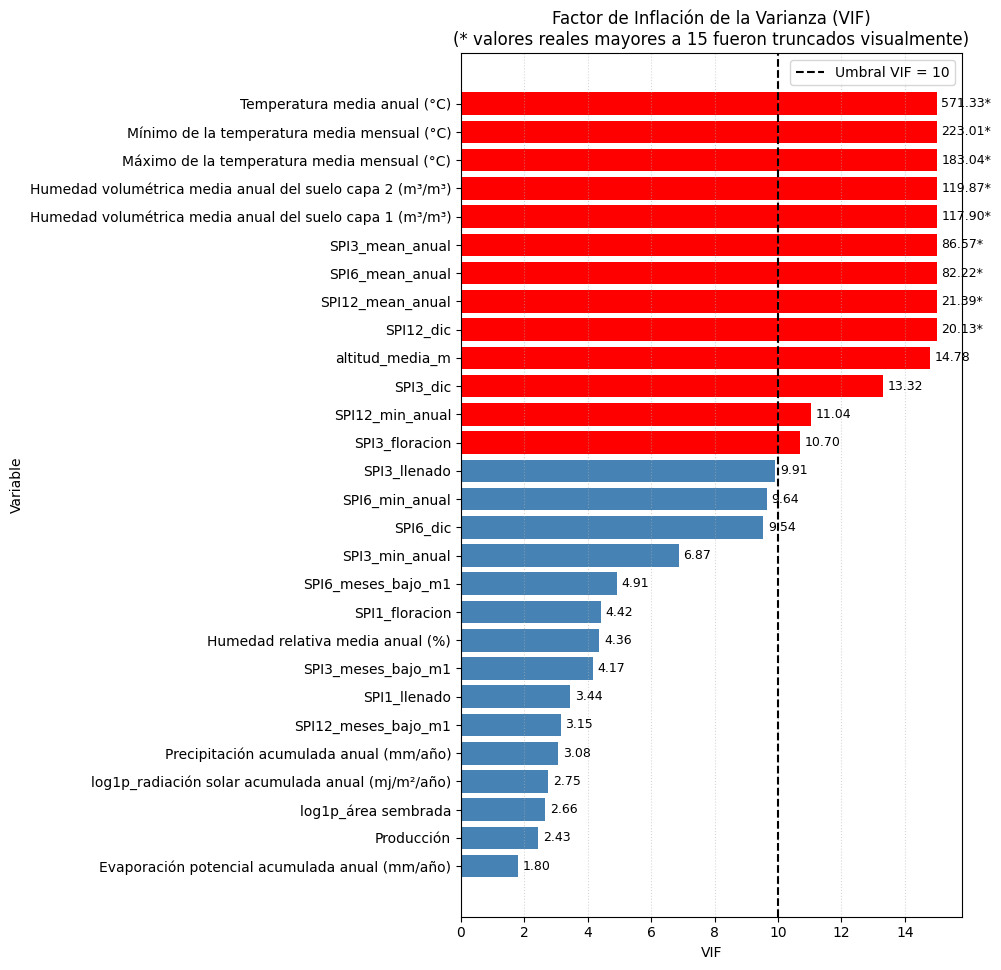

In [107]:

vif_plot = tabla_vif.copy()

# Asegurar tipo numérico
vif_plot["VIF"] = pd.to_numeric(vif_plot["VIF"], errors="coerce")

# Eliminar nulos si existen
vif_plot = vif_plot.dropna(subset=["VIF"]).copy()

# Ordenar para que se vea mejor
vif_plot = vif_plot.sort_values("VIF", ascending=True)

# =========================
# 2. Cortar visualmente en 15
# =========================

vif_plot["VIF_plot"] = vif_plot["VIF"].clip(upper=15)

# Colores: resaltar > 10
vif_plot["color"] = np.where(vif_plot["VIF"] > 10, "red", "steelblue")

# =========================
# 3. Gráfica
# =========================

plt.figure(figsize=(10, max(6, len(vif_plot) * 0.35)))

bars = plt.barh(
    vif_plot["variable"],
    vif_plot["VIF_plot"],
    color=vif_plot["color"]
)

# Línea de referencia en VIF = 10
plt.axvline(x=10, linestyle="--", linewidth=1.5, color="black", label="Umbral VIF = 10")

# Etiquetas con el valor real
for i, (vif_real, vif_vis) in enumerate(zip(vif_plot["VIF"], vif_plot["VIF_plot"])):
    if vif_real > 15:
        etiqueta = f"{vif_real:.2f}*"
    else:
        etiqueta = f"{vif_real:.2f}"
    
    plt.text(
        vif_vis + 0.15,
        i,
        etiqueta,
        va="center",
        fontsize=9
    )

plt.xlim(0, 15.8)
plt.xlabel("VIF")
plt.ylabel("Variable")
plt.title("Factor de Inflación de la Varianza (VIF)\n(* valores reales mayores a 15 fueron truncados visualmente)")
plt.legend()
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### PCA

In [108]:
df_pca = df_final.copy()


df_pca = df_pca.sort_values(id_cols + [time_col]).reset_index(drop=True)

print(df_pca.shape)
display(df_pca.head())

(1481, 31)


,Departamento,Municipio,Año,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad relativa media anual (%),Humedad volumétrica media anual del suelo capa 1 (m³/m³),...,SPI3_dic,SPI6_dic,SPI12_dic,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,log1p_área sembrada,log1p_radiación solar acumulada anual (mj/m²/año)
0,CUNDINAMARCA,ANAPOIMA,2008,0.443322,9397.211458,21.052603,21.534576,20.717682,83.73498,0.410168,...,-0.660129,0.442474,0.990945,0.034885,0.288161,-0.041813,0.090587,753.137185,5.462390,8.600787
1,CUNDINAMARCA,ANAPOIMA,2009,0.458047,7596.002594,21.659576,22.564850,21.122711,82.47872,0.408908,...,-1.038473,-0.650928,-0.561965,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,5.479263,8.646946
2,CUNDINAMARCA,ANAPOIMA,2010,0.467144,10091.935886,21.505259,23.381012,19.950592,84.22712,0.409552,...,-0.475811,0.739385,1.536935,0.060390,0.094568,0.601869,0.299247,753.137185,5.502278,8.573215
3,CUNDINAMARCA,ANAPOIMA,2011,0.473469,8696.465524,21.023651,21.647125,20.361969,85.47486,0.411489,...,-0.484511,-0.099035,0.412532,0.015540,0.021867,0.398428,0.166396,753.137185,5.505332,8.580160
4,CUNDINAMARCA,ANAPOIMA,2012,0.500000,7848.365871,21.446869,21.943756,20.838287,81.22755,0.407908,...,-0.608266,-0.362650,-0.330545,-0.069946,-0.136889,-0.022393,0.012682,753.137185,4.682131,8.629495


In [109]:
# =========================
# Crear target futuro
# =========================

grupo = df_pca.groupby(id_cols)

df_pca["rendimiento_t1"] = grupo[target_col].shift(-1)
df_pca["anio_t1"] = grupo[time_col].shift(-1)

# Validar continuidad: el siguiente registro debe ser exactamente t + 1
df_pca.loc[
    df_pca["anio_t1"] != df_pca[time_col] + 1,
    "rendimiento_t1"
] = np.nan

print("Filas con target futuro válido:", df_pca["rendimiento_t1"].notna().sum())

Filas con target futuro válido: 1376


In [110]:
# =========================
# Rezagos seguros
# =========================

df_pca["Rendimiento_lag1"] = grupo[target_col].shift(1)
df_pca["Rendimiento_lag2"] = grupo[target_col].shift(2)
df_pca["Rendimiento_lag3"] = grupo[target_col].shift(3)

df_pca["diff_lag1"] = grupo[time_col].diff(1)
df_pca["diff_lag2"] = grupo[time_col].diff(2)
df_pca["diff_lag3"] = grupo[time_col].diff(3)

df_pca.loc[df_pca["diff_lag1"] != 1, "Rendimiento_lag1"] = np.nan
df_pca.loc[df_pca["diff_lag2"] != 2, "Rendimiento_lag2"] = np.nan
df_pca.loc[df_pca["diff_lag3"] != 3, "Rendimiento_lag3"] = np.nan

# Promedio móvil histórico
df_pca["Rendimiento_rolling3"] = (
    grupo[target_col]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

# Media histórica municipal previa
media_mun = (
    grupo[target_col]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_pca["Rendimiento_vs_media_mun"] = df_pca["Rendimiento_lag1"] - media_mun

In [111]:
# =========================
# Selección de predictores numéricos
# =========================

excluir = [
    target_col,
    "rendimiento_t1",
    "anio_t1",
    "diff_lag1",
    "diff_lag2",
    "diff_lag3"
]

numeric_cols = df_pca.select_dtypes(include=[np.number]).columns.tolist()

features_pca = [
    c for c in numeric_cols
    if c not in excluir
]

# Opcional: quitar el año si no quieres que PCA capture tendencia temporal pura
features_pca = [c for c in features_pca if c != time_col]

print("Número de variables para PCA:", len(features_pca))
print(features_pca)

Número de variables para PCA: 32
['Precipitación acumulada anual (mm/año)', 'Temperatura media anual (°C)', 'Máximo de la temperatura media mensual (°C)', 'Mínimo de la temperatura media mensual (°C)', 'Humedad relativa media anual (%)', 'Humedad volumétrica media anual del suelo capa 1 (m³/m³)', 'Humedad volumétrica media anual del suelo capa 2 (m³/m³)', 'Evaporación potencial acumulada anual (mm/año)', 'SPI3_mean_anual', 'SPI3_min_anual', 'SPI3_meses_bajo_m1', 'SPI6_mean_anual', 'SPI6_min_anual', 'SPI6_meses_bajo_m1', 'SPI12_mean_anual', 'SPI12_min_anual', 'SPI12_meses_bajo_m1', 'SPI3_dic', 'SPI6_dic', 'SPI12_dic', 'SPI1_floracion', 'SPI3_floracion', 'SPI1_llenado', 'SPI3_llenado', 'altitud_media_m', 'log1p_área sembrada', 'log1p_radiación solar acumulada anual (mj/m²/año)', 'Rendimiento_lag1', 'Rendimiento_lag2', 'Rendimiento_lag3', 'Rendimiento_rolling3', 'Rendimiento_vs_media_mun']


In [112]:
features_clima = [
    c for c in features_pca
    if c not in [
        "Rendimiento_lag1",
        "Rendimiento_lag2",
        "Rendimiento_lag3",
        "Rendimiento_rolling3",
        "Rendimiento_vs_media_mun"
    ]
]

features_todas = features_pca

In [113]:
# =========================
# Base modelable
# =========================

df_model = df_pca.dropna(subset=["rendimiento_t1"] + features_pca).copy()

print(df_model.shape)
print(df_model[time_col].min(), df_model[time_col].max())

(1075, 41)
2011 2023


In [114]:
train = df_model[df_model[time_col] <= 2020].copy()
valid = df_model[(df_model[time_col] >= 2021) & (df_model[time_col] <= 2022)].copy()
test  = df_model[df_model[time_col] == 2023].copy()

print(train.shape, valid.shape, test.shape)

(816, 41) (173, 41) (86, 41)


In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = train[features_pca]
X_valid = valid[features_pca]
X_test = test[features_pca]

y_train = train["rendimiento_t1"]
y_valid = valid["rendimiento_t1"]
y_test = test["rendimiento_t1"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [116]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

tabla_varianza = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(var_exp))],
    "varianza_explicada": var_exp,
    "varianza_acumulada": var_acum
})

tabla_varianza["varianza_explicada"] = tabla_varianza["varianza_explicada"].round(4)
tabla_varianza["varianza_acumulada"] = tabla_varianza["varianza_acumulada"].round(4)

display(tabla_varianza)

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.2995,0.2995
1,PC2,0.1631,0.4626
2,PC3,0.1045,0.5671
3,PC4,0.0801,0.6471
4,PC5,0.0646,0.7117
5,PC6,0.0591,0.7709
6,PC7,0.0432,0.8141
7,PC8,0.0311,0.8452
8,PC9,0.0267,0.8719
9,PC10,0.0231,0.8950


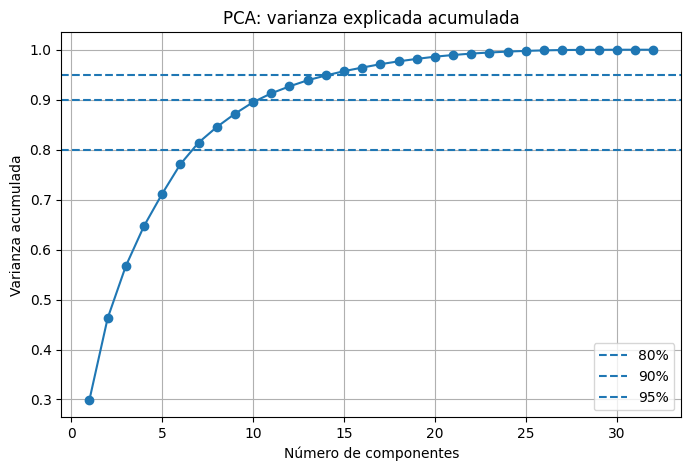

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(var_acum) + 1),
    var_acum,
    marker="o"
)
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA: varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.show()

### Validacion modelo con PCA

In [143]:
import pandas as pd
import numpy as np

# =========================
# 1. Extraer scaler y PCA del pipeline ya entrenado
# =========================

scaler_pca = modelo_pca.named_steps["scaler"]
pca_model = modelo_pca.named_steps["pca"]

# Número de componentes
k = pca_model.n_components_

cols_pc = [f"PC{i+1}" for i in range(k)]

In [144]:
# =========================
# 2. Transformar X_train y X_valid
# =========================

X_train_scaled = scaler_pca.transform(X_train)
X_valid_scaled = scaler_pca.transform(X_valid)

X_train_pca = pca_model.transform(X_train_scaled)
X_valid_pca = pca_model.transform(X_valid_scaled)

df_train_pca = pd.DataFrame(
    X_train_pca,
    columns=cols_pc,
    index=X_train.index
)

df_valid_pca = pd.DataFrame(
    X_valid_pca,
    columns=cols_pc,
    index=X_valid.index
)

In [145]:
# =========================
# 3. Columnas base a conservar
# =========================

cols_base = [
    "Departamento",
    "Municipio",
    "anio",
    "rendimiento",
    "rendimiento_t1"
]

cols_base = [c for c in cols_base if c in train.columns]

# =========================
# 4. Unir identificadores + target + componentes PCA
# =========================

Base_train_pca = pd.concat(
    [
        train[cols_base],
        df_train_pca
    ],
    axis=1
)

Base_valid_pca = pd.concat(
    [
        valid[cols_base],
        df_valid_pca
    ],
    axis=1
)

# =========================
# 5. Unir train + valid
# =========================

Base_data_fe_pca_reduction = pd.concat(
    [
        Base_train_pca,
        Base_valid_pca
    ],
    axis=0
).sort_index()

print(Base_data_fe_pca_reduction.shape)
display(Base_data_fe_pca_reduction.head())

(989, 13)


,Departamento,Municipio,rendimiento_t1,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
3,CUNDINAMARCA,ANAPOIMA,0.500000,3.472391,4.118557,-2.628687,0.574273,-0.689940,0.614550,-0.409115,-1.013575,-0.089795,-0.214145
4,CUNDINAMARCA,ANAPOIMA,0.448871,1.906759,4.246644,-2.715799,0.065222,-0.538814,0.483589,0.049661,-0.127347,0.089921,-0.868196
5,CUNDINAMARCA,ANAPOIMA,0.485360,1.870001,4.084492,-2.297163,1.703948,-0.472716,0.327553,-0.100119,-0.395422,-0.945512,0.500082
6,CUNDINAMARCA,ANAPOIMA,0.798320,2.395305,4.324597,-2.458513,0.300670,-0.516558,0.420251,-0.060915,-0.603437,-0.603850,-0.507712
7,CUNDINAMARCA,ANAPOIMA,0.825623,1.545309,4.069344,-2.260678,0.919269,-0.474343,-0.120053,0.044113,-0.929069,-0.634462,-0.766958


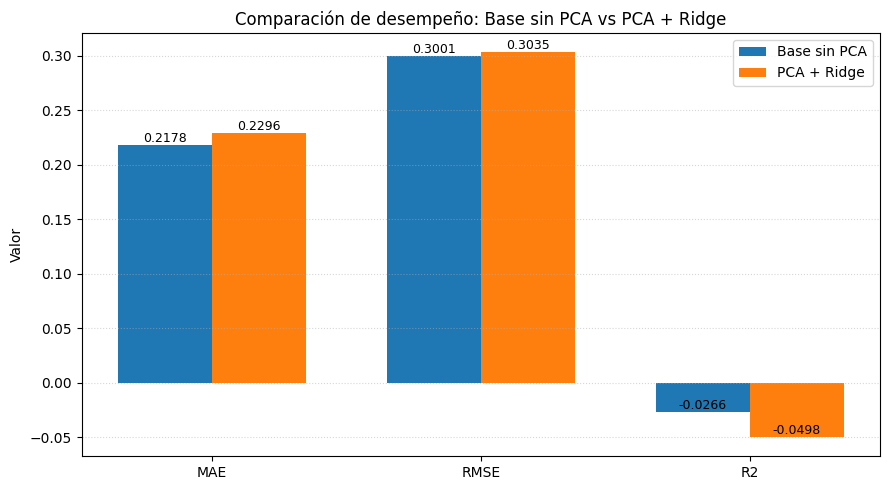

In [146]:

metricas = ["MAE", "RMSE", "R2"]
modelos = comparacion["modelo"].tolist()

x = np.arange(len(metricas))
width = 0.35

valores_base = comparacion.loc[comparacion["modelo"] == "Base sin PCA", metricas].values.flatten()
valores_pca = comparacion.loc[comparacion["modelo"] == "PCA + Ridge", metricas].values.flatten()

# =========================
# 2. Gráfica
# =========================

plt.figure(figsize=(9, 5))

bars1 = plt.bar(x - width/2, valores_base, width, label="Base sin PCA")
bars2 = plt.bar(x + width/2, valores_pca, width, label="PCA + Ridge")

# Etiquetas de valores
for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.4f}", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.4f}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, metricas)
plt.ylabel("Valor")
plt.title("Comparación de desempeño: Base sin PCA vs PCA + Ridge")
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### Guardar data set con reduccion de PCA

In [ ]:
# =========================
# 7. Varianza explicada por PCA
# =========================

varianza_pca = pd.DataFrame({
    "componente": cols_pc,
    "varianza_explicada": pca_model.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca_model.explained_variance_ratio_)
})

varianza_pca["varianza_explicada"] = varianza_pca["varianza_explicada"].round(4)
varianza_pca["varianza_acumulada"] = varianza_pca["varianza_acumulada"].round(4)

display(varianza_pca)

varianza_pca.to_csv(
    "varianza_pca.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# =========================
# 8. Loadings PCA
# =========================

loadings_pca = pd.DataFrame(
    pca_model.components_.T,
    index=X_train.columns,
    columns=cols_pc
)

display(loadings_pca)

loadings_pca.to_csv(
    "loadings_pca.csv",
    encoding="utf-8-sig"
)

In [ ]:
# =========================
# 9. Variables originales usadas en PCA
# =========================

variables_usadas_pca = pd.DataFrame({
    "variable_original": X_train.columns
})

display(variables_usadas_pca)

variables_usadas_pca.to_csv(
    "variables_usadas_pca.csv",
    index=False,
    encoding="utf-8-sig"
)